<a href="https://colab.research.google.com/github/zcflanzer/rcew-water-budget/blob/main/VegetationCover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Vegetation cover**
**Author:** Zoe Flanzer\
**Last updated:** 5/15/2026\
**Purpose:** To retrieve vegetation cover data and explore vegetation cover change.

**Data from:** https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2023_REL_RCMAP_V6_COVER#description

In [1]:
## setting up notebook
# importing important libraries
!pip install earthengine-api geemap moviepy seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime
from geemap import add_text_to_gif

# Authenticate & initialize Earth Engine
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize(project = 'ee-zoeflanzer') # change project name

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
## importing data
# full catchment veg cover
data = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Vegetation/cover.csv')

# defining veg variables
year = data['year']
afg = data['AFG'] # annual forbs and grasses
pfg = data['PFG'] # perennial forbs and grasses
shr = data['SHR'] # shrubs
tre = data['TRE'] # tree cover
ltr = data['LTR'] # litter
bgr = data['BGR'] # bare ground
annualtemp =  data['annualTemp'] # from RCMAP dataset
annualprecip = data['annualPrecip'] # from RCMAP dataset

In [3]:
## importing all shapefiles
# full tollgate shapefile
shp = gpd.read_file('/content/drive/MyDrive/Thesis/Data/Shapefiles/tollgate_edited.shp') # importing shape file

# setting crs
if shp.crs is None:
   shp.crs = 'EPSG:26911'
shp = shp.to_crs('EPSG:4326') # reprojecting to correspond to OpenET

# converting shapefile to GEE feature
fc = geemap.geopandas_to_ee(shp)

# elevation quartile shapefiles
shp_Q1 = gpd.read_file('/content/drive/MyDrive/Thesis/Data/Other/hypsometric_quartiles_APPROX/contour_quartile_1.shp')
shp_Q2 = gpd.read_file('/content/drive/MyDrive/Thesis/Data/Other/hypsometric_quartiles_APPROX/contour_quartile_2.shp')
shp_Q3 = gpd.read_file('/content/drive/MyDrive/Thesis/Data/Other/hypsometric_quartiles_APPROX/contour_quartile_3.shp')
shp_Q4 = gpd.read_file('/content/drive/MyDrive/Thesis/Data/Other/hypsometric_quartiles_APPROX/contour_quartile_4.shp')

# reprojecting shapefiles from nad83 to wgs84
shp_Q1 = shp_Q1.to_crs('EPSG:4326')
shp_Q2 = shp_Q2.to_crs('EPSG:4326')
shp_Q3 = shp_Q3.to_crs('EPSG:4326')
shp_Q4 = shp_Q4.to_crs('EPSG:4326')

# converting shapefiles to GEE features
fc_Q1 = geemap.geopandas_to_ee(shp_Q1)
fc_Q2 = geemap.geopandas_to_ee(shp_Q2)
fc_Q3 = geemap.geopandas_to_ee(shp_Q3)
fc_Q4 = geemap.geopandas_to_ee(shp_Q4)

In [4]:
## defining dates for analysis
start_date = '2020-10-01' # single year test and map
end_date = '2021-09-30' # single year test and map

start_yr = 2000 # multi-year loop
end_yr = 2024 # multi-year loop

**Plotting RCMAP data for full catchment**

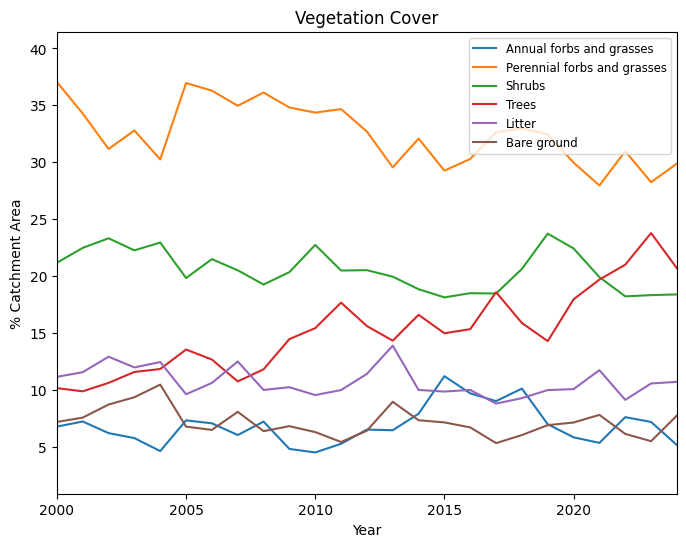

In [5]:
## plotting RCMAP vegetation cover
fig, veg_cover = plt.subplots(figsize = (8, 6))
plt.plot(year, afg, label = 'Annual forbs and grasses')
plt.plot(year, pfg, label = 'Perennial forbs and grasses')
plt.plot(year, shr, label = 'Shrubs')
plt.plot(year, tre, label = 'Trees')
plt.plot(year, ltr, label = 'Litter')
plt.plot(year, bgr, label = 'Bare ground')
plt.xlabel('Year')
plt.ylabel('% Catchment Area')
plt.title('Vegetation Cover')
plt.xlim(2000, 2024)
plt.legend(fontsize='small', loc = 'upper right', frameon=True)
plt.show()

# saving figure
fig.savefig('veg_cover.png', dpi=300, bbox_inches='tight')

**Plotting RCMAP data for elevation quartiles**

In [6]:
## Mapping one year of RCMAP data by quartile
param = 'tree cover' # vegetation type to plot

# calculating centroid to center the map
centroid = shp_Q1.geometry.unary_union.centroid
centroid_lon = centroid.x
centroid_lat = centroid.y

# importing one year of veg data
veg_data_Q1 = ee.ImageCollection("USGS/NLCD_RELEASES/2023_REL/RCMAP/V6/COVER").filter(ee.Filter.date(start_date, end_date)).filterBounds(fc_Q1).select('rangeland_tree').sum()
veg_data_Q2 = ee.ImageCollection("USGS/NLCD_RELEASES/2023_REL/RCMAP/V6/COVER").filter(ee.Filter.date(start_date, end_date)).filterBounds(fc_Q2).select('rangeland_tree').sum()
veg_data_Q3 = ee.ImageCollection("USGS/NLCD_RELEASES/2023_REL/RCMAP/V6/COVER").filter(ee.Filter.date(start_date, end_date)).filterBounds(fc_Q3).select('rangeland_tree').sum()
veg_data_Q4 = ee.ImageCollection("USGS/NLCD_RELEASES/2023_REL/RCMAP/V6/COVER").filter(ee.Filter.date(start_date, end_date)).filterBounds(fc_Q4).select('rangeland_tree').sum()

# create map
Map = geemap.Map(center=[centroid_lat, centroid_lon], zoom=12)

# adding quartile boundaries to map
Map.addLayer(fc_Q1, {'color': 'black'}, 'Q1 Boundary')
Map.addLayer(fc_Q2, {'color': 'black'}, 'Q2 Boundary')
Map.addLayer(fc_Q3, {'color': 'black'}, 'Q3 Boundary')
Map.addLayer(fc_Q4, {'color': 'black'}, 'Q4 Boundary')

# defining how data will be visualized
vis_params = {'min': 0,'max': 100,'palette': ['#d9c7a1', '#c19a6b', '#7fbf7f', '#2a924a', '#0b4f0b']} # tan (no trees) ==> dark green (dense trees)

# adding data to map
veg_data_layer_Q1 = veg_data_Q1.clip(fc_Q1).visualize(**vis_params) # quartile 1
Map.addLayer(veg_data_layer_Q1, {}, f'{param} Q1')
veg_data_layer_Q2 = veg_data_Q2.clip(fc_Q2).visualize(**vis_params) # quartile 2
Map.addLayer(veg_data_layer_Q2, {}, f'{param} Q2')
veg_data_layer_Q3 = veg_data_Q3.clip(fc_Q3).visualize(**vis_params) # quartile 3
Map.addLayer(veg_data_layer_Q3, {}, f'{param} Q3')
veg_data_layer_Q4 = veg_data_Q4.clip(fc_Q4).visualize(**vis_params) # quartile 4
Map.addLayer(veg_data_layer_Q4, {}, f'{param} Q4')

# Display the map
Map

/tmp/ipykernel_57103/1865356228.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = shp_Q1.geometry.unary_union.centroid


Map(center=[43.12076508924756, -116.77140298681024], controls=(WidgetControl(options=['position', 'transparent…

In [7]:
## creating function to pull tree cover data from GEE RCMAP for multiple years
def get_annual_treecover(quartile_label, start_yr, end_yr, param='tree cover'):
    quartile_map = {'Q1': fc_Q1,'Q2': fc_Q2,'Q3': fc_Q3,'Q4': fc_Q4}

    if quartile_label not in quartile_map:
        raise ValueError("quartile_label must be one of: 'Q1', 'Q2', 'Q3', 'Q4'")

    fc = quartile_map[quartile_label]
    annual_values = []

    for year in range(start_yr, end_yr):

        # filtering by year
        img = (ee.ImageCollection('USGS/NLCD_RELEASES/2023_REL/RCMAP/V6/COVER').filter(ee.Filter.calendarRange(year, year, 'year')).filterBounds(fc).select('rangeland_tree').sum())

        # ensuring images exists
        if img is None:
            annual_values.append([year, None])
            continue

        projection = img.projection()

        mean_val = img.reduceRegion(reducer=ee.Reducer.mean(),geometry=fc.geometry(),scale=30,crs=projection).get('rangeland_tree').getInfo()

        annual_values.append([year, mean_val])

    df = pd.DataFrame(annual_values, columns=['Year', f'{param}'])
    return df


In [8]:
df_Q1 = get_annual_treecover('Q1', start_yr, end_yr)

In [9]:
df_Q2 = get_annual_treecover('Q2', start_yr, end_yr)

In [10]:
df_Q3 = get_annual_treecover('Q3', start_yr, end_yr)

In [11]:
df_Q4 = get_annual_treecover('Q4', start_yr, end_yr)

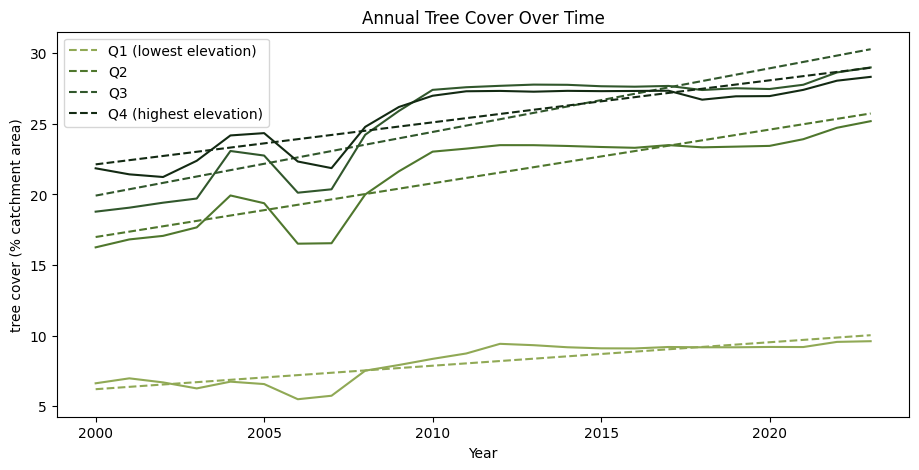

slope Q1 = 0.16628255541527104
slope Q2 = 0.38038172054431524
slope Q3 = 0.45076163348852677
slope Q4 = 0.2975696255932535


In [12]:
## plotting quartile data by year on the same fig
plt.figure(figsize=(11, 5))

# Q1
plt.plot(df_Q1['Year'], df_Q1[f'{param}'], linestyle='-', color = '#90A955')
slope_Q1, intercept = np.polyfit(df_Q1['Year'], df_Q1[f'{param}'], 1)
plt.plot(df_Q1['Year'], slope_Q1 * df_Q1['Year'] + intercept, 'r', label='Q1 (lowest elevation)', color = '#90A955', linestyle = '--')

# Q2
plt.plot(df_Q2['Year'], df_Q2[f'{param}'], linestyle='-', color = '#4F772D')
slope_Q2, intercept = np.polyfit(df_Q2['Year'], df_Q2[f'{param}'], 1)
plt.plot(df_Q2['Year'], slope_Q2 * df_Q2['Year'] + intercept, 'r', label='Q2', color = '#4F772D', linestyle = '--')

# Q3
plt.plot(df_Q3['Year'], df_Q3[f'{param}'], linestyle='-', color = '#31572C')
slope_Q3, intercept = np.polyfit(df_Q3['Year'], df_Q3[f'{param}'], 1)
plt.plot(df_Q3['Year'], slope_Q3 * df_Q3['Year'] + intercept, 'r', label='Q3', color = '#31572C', linestyle = '--')

# Q4
plt.plot(df_Q4['Year'], df_Q4[f'{param}'], linestyle='-', color = '#132A13')
slope_Q4, intercept = np.polyfit(df_Q4['Year'], df_Q4[f'{param}'], 1)
plt.plot(df_Q4['Year'], slope_Q4 * df_Q4['Year'] + intercept, 'r', label='Q4 (highest elevation)', color = '#132A13', linestyle = '--')

# general formatting
plt.title(f'Annual Tree Cover Over Time')
plt.xlabel('Year')
plt.ylabel(f'{param} (% catchment area)')
plt.legend()
plt.show()

# printing linear slope of all quartiles
print(f'slope Q1 = {slope_Q1}')
print(f'slope Q2 = {slope_Q2}')
print(f'slope Q3 = {slope_Q3}')
print(f'slope Q4 = {slope_Q4}')

In [13]:
## saving quartile data as CSVs
df_Q1.to_csv("treecover_Q1.csv", index=False)
df_Q2.to_csv("treecover_Q2.csv", index=False)
df_Q3.to_csv("treecover_Q3.csv", index=False)
df_Q4.to_csv("treecover_Q4.csv", index=False)